# Pakistan District Socioeconomic Patterns: A Spatial EDA

This project examines literacy and sanitation access across Pakistan's districts using open government survey data (PSLM 2019-20), mapped against real administrative boundaries. It builds on the GIS skills developed in my Nepal earthquake analysis — specifically extending from point-based mapping (earthquake epicenters) to polygon-based choropleth mapping (districts colored by indicator values), a technique not covered in that earlier project.

Literacy and sanitation access were chosen together deliberately: this pairing mirrors the structure of the internationally recognized Multidimensional Poverty Index, which combines education and living-standard indicators to measure poverty — not an arbitrary combination.

## Setup

pandas and geopandas for tabular and spatial data handling; matplotlib for the choropleth maps.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## Loading the data

Three sources are combined: district boundary polygons (fetched live from a GitHub-hosted GeoJSON, since Pakistan's official boundaries aren't available as a simple direct download), literacy rates by district, and toilet/sanitation access by district — both from Pakistan's 2019-20 PSLM household survey (the most recent completed survey round; a 2026 round is mid-fieldwork and not yet published). `on_invalid="fix"` repairs a malformed polygon in the boundary file that otherwise crashes on load.

In [2]:
districts = gpd.read_file(
    "https://raw.githubusercontent.com/pakdata/gisdata/master/PAK-GeoJSON/PAK_adm3.json",
    on_invalid="fix"
)
literacy = pd.read_csv("literacy.csv")   # adjust filename to match yours
toilet = pd.read_csv("toilet.csv")

print(districts.shape, literacy.shape, toilet.shape)

(141, 17) (126, 11) (129, 5)


All three load successfully: 141 districts in the boundary file, 126 in the literacy survey, 129 in the toilet-access survey. The row counts don't match — explained in the data quality section below.

Checking structure and column names across all three sources before attempting any join, since they come from unrelated systems and are unlikely to share a common format.

In [3]:
for name, d in [("Districts (boundaries)", districts), ("Literacy", literacy), ("Toilet", toilet)]:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print("Shape:", d.shape)
    print("\nColumns:", d.columns.tolist())
    print("\nData types:")
    print(d.dtypes)
    print("\nFirst 3 rows:")
    print(d.head(3))


Districts (boundaries)
Shape: (141, 17)

Columns: ['GID_0', 'NAME_0', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'GID_3', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']

Data types:
GID_0             str
NAME_0            str
GID_1             str
NAME_1            str
NL_NAME_1      object
GID_2             str
NAME_2            str
NL_NAME_2      object
GID_3             str
NAME_3            str
VARNAME_3         str
NL_NAME_3      object
TYPE_3            str
ENGTYPE_3         str
CC_3           object
HASC_3         object
geometry     geometry
dtype: object

First 3 rows:
  GID_0    NAME_0    GID_1        NAME_1 NL_NAME_1      GID_2        NAME_2  \
0   PAK  Pakistan  PAK.1_1  Azad Kashmir      None  PAK.1.1_1  Azad Kashmir   
1   PAK  Pakistan  PAK.1_1  Azad Kashmir      None  PAK.1.1_1  Azad Kashmir   
2   PAK  Pakistan  PAK.1_1  Azad Kashmir      None  PAK.1.1_1  Azad Kashmir   

  NL_NAME_2        GID_3   NAME_3 

**districts** carries a geometry column plus name/province columns (NAME_1=province, NAME_3=district) — the spatial "canvas." **literacy and toilet** are both PSLM exports sharing the same structure (ProvinceID, Name, then numeric columns) — but ProvinceID is a PSLM-only code with no equivalent in the boundary file, so a name-based join is required. Numeric columns in literacy/toilet are correctly typed as int64. Several boundary columns (NL_NAME_1/2/3, HASC_3) are empty throughout and are not used. `VARNAME_3` holds real alternate spellings for 118 of 141 districts, several of which independently corroborate naming fixes worked out by hand below.

## Data quality investigation: district name mismatches

Before any analysis, district names across all three sources needed reconciling, since none share a common ID system — a name-based join is the only option. Names are spelled inconsistently across sources (e.g. "Bajaur" vs "Bajur", "D.I.Khan" vs "Dera Ismail Khan"), so an exact-string join would silently fail for many districts.

In [4]:
boundary_names = set(districts["NAME_3"].str.strip().str.lower())
literacy_names = set(literacy["Name"].str.strip().str.lower())
toilet_names = set(toilet["Name"].str.strip().str.lower())

print(f"In boundaries but not literacy ({len(boundary_names - literacy_names)}):")
print(sorted(boundary_names - literacy_names))

print(f"\nIn boundaries but not toilet ({len(boundary_names - toilet_names)}):")
print(sorted(boundary_names - toilet_names))

In boundaries but not literacy (57):
['adam khel', 'attok', 'bagh', 'bajaur', 'battagram', 'bhakkar', 'bhimber', 'bhittani', 'bolan', 'chagai', 'chilas', 'dera ghazi kha', 'dera ismail khan', 'dir', 'disputed area 1', 'disputed area 2', 'gilgit', 'gilgit (tribal territory)', 'gujarat', 'gujranwala 1', 'gujranwala 2', 'jafarabad', 'jakobabad', 'jhal magsi', 'kargil', 'kech', 'kholu', 'kotli', 'kupwara (gilgit wazarat)', 'ladakh (leh)', 'largha shirani', 'malakand p.a.', 'malir', 'mirphurkhas', 'mirpur', 'mithi', 'musakhel', 'muzaffarabad', 'muzaffargarh', 'n. waziristan', 'narowal 1', 'narowal 2', 'naushahro firoz', 'nawab shah', 'neelum', 'okara 1', 'panjgur', 'poonch', 'rahimyar khan', 'rajan pur', 'rann of kutch', 's. waziristan', 'sudhnati', 'tando allahyar', 'tando m. khan', 'umerkot', 'zhob']

In boundaries but not toilet (52):
['adam khel', 'attok', 'bagh', 'bajaur', 'battagram', 'bhimber', 'bhittani', 'bolan', 'chilas', 'dera ghazi kha', 'dera ismail khan', 'dir', 'disputed area

Most mismatches were spelling or abbreviation differences. A few boundary-file entries (Gujranwala 1/2, Narowal 1/2) split one PSLM district into sub-areas and were merged back. Districts were deliberately left unmatched for three distinct reasons: Azad Kashmir and Gilgit-Baltistan districts (e.g. Bagh, Muzaffarabad, Gilgit) are administered separately from Pakistan's four provinces and fall outside PSLM's scope; several disputed-territory entries (Kargil, Ladakh, Rann of Kutch) fall outside Pakistan's administration entirely; and a handful of remote districts were simply not covered in this survey round. Three further districts — Musakhel, Largha Shirani, Sheerani — remain genuinely ambiguous and were left unmapped rather than guessed.

**A key finding during this process:** literacy and toilet don't always need the *same* correction for the same district — the two PSLM exports sometimes spell the same place differently from each other, not just from the boundary file (Mirphurkhas alone has three different spellings across the three files: "Mirphurkhas", "Mir Pur Khas", "Mirpur Khas"). The two rename maps below were built and verified independently for this reason, each checked against that specific file's actual data rather than assumed from the other.

In [5]:
rename_map_literacy = {
    "attok": "attock", "battagram": "batagram", "bhakkar": "bhakhar",
    "dera ghazi kha": "d.g.khan", "dera ismail khan": "d.i.khan",
    "jafarabad": "jaffarabad", "jakobabad": "jacobabad", "kech": "ketch",
    "kholu": "kohlu", "malakand p.a.": "malakand pa",
    "mirphurkhas": "mir pur khas",
    "muzaffargarh": "muzaffar garh", "n. waziristan": "north waziristan",
    "naushahro firoz": "naushahro feroze", "rahimyar khan": "rahim yar khan",
    "rajan pur": "rajanpur", "s. waziristan": "south waziristan",
    "tando allahyar": "tando allah yar", "tando m. khan": "tando muhammad khan",
    "umerkot": "umer kot", "gujranwala 1": "gujranwala", "gujranwala 2": "gujranwala",
    "narowal 1": "narowal", "narowal 2": "narowal", "okara 1": "okara",
    "mithi": "tharparkar", "nawab shah": "shaheed benazirabad",
}

rename_map_toilet = {
    "attok": "attock", "battagram": "batagram",
    "dera ghazi kha": "d.g.khan", "dera ismail khan": "d.i.khan",
    "jakobabad": "jacobabad", "kech": "ketch", "kholu": "kohlu",
    "malakand p.a.": "malakand pa",
    "mirphurkhas": "mirpur khas",
    "n. waziristan": "north waziristan", "naushahro firoz": "naushahro feroze",
    "rahimyar khan": "rahim yar khan", "rajan pur": "rajanpur",
    "s. waziristan": "south waziristan", "tando allahyar": "tando allah yar",
    "tando m. khan": "tando muhammad khan", "gujranwala 1": "gujranwala",
    "gujranwala 2": "gujranwala", "narowal 1": "narowal", "narowal 2": "narowal",
    "okara 1": "okara", "mithi": "tharparkar", "nawab shah": "shaheed benazirabad",
    "qilla abdullah": "killa abdullah", "qilla saifullah": "killa saifullah",
    "bajaur": "bajur",
    # jafarabad genuinely absent from the toilet survey - not a spelling issue
    # bhakkar, muzaffargarh, umerkot deliberately not renamed here -
    # boundary's raw spelling already matched toilet directly for these three
}

districts["key_literacy"] = districts["NAME_3"].str.strip().str.lower().replace(rename_map_literacy)
districts["key_toilet"] = districts["NAME_3"].str.strip().str.lower().replace(rename_map_toilet)
literacy["key_literacy"] = literacy["Name"].str.strip().str.lower()
toilet["key_toilet"] = toilet["Name"].str.strip().str.lower()

## Joining boundaries with survey data

With independent join keys built for each survey, the boundary file is merged with literacy and toilet-access data using a left join — every district in the boundary file is kept, even where no survey match exists, so unmatched districts appear with blank values rather than disappearing.

In [6]:
merged = districts.merge(literacy, on="key_literacy", how="left", suffixes=("", "_literacy"))
merged = merged.merge(toilet, on="key_toilet", how="left", suffixes=("_literacy", "_toilet"))

print(f"Total districts: {len(merged)}")
print(f"Matched literacy: {merged['Total_literacy'].notna().sum()}")
print(f"Matched toilet: {merged['Total_toilet'].notna().sum()}")

literacy_only = merged[merged["Total_literacy"].notna() & merged["Total_toilet"].isna()]
toilet_only = merged[merged["Total_toilet"].notna() & merged["Total_literacy"].isna()]
print(f"\nMatched literacy but NOT toilet ({len(literacy_only)}):", literacy_only["NAME_3"].tolist())
print(f"Matched toilet but NOT literacy ({len(toilet_only)}):", toilet_only["NAME_3"].tolist())

Total districts: 141
Matched literacy: 111
Matched toilet: 114

Matched literacy but NOT toilet (1): ['Jafarabad']
Matched toilet but NOT literacy (4): ['Panjgur', 'Jhal Magsi', 'Chagai', 'Zhob']


The join achieved 111 of 141 districts (79%) matched with literacy and 114 of 141 (81%) matched with toilet — 110 districts matched both. Five districts remain unmatched due to genuine survey coverage gaps rather than naming errors: Jafarabad appears in the literacy survey but not toilet; Panjgur, Jhal Magsi, Chagai, and Zhob appear in the toilet survey but not literacy. **All five are Baluchistan districts** — a real pattern suggesting the two PSLM 2019-20 survey modules had inconsistent coverage specifically in that province, likely reflecting genuine logistical or access difficulties conducting fieldwork there. This is a finding about the data itself, not a defect to fix.

(Note: the boundary file spells the province "Baluchistan" and uses several older administrative names — "N.W.F.P." for present-day Khyber Pakhtunkhwa, "Sind" for Sindh, "Northern Areas" for Gilgit-Baltistan — reflecting the vintage of this particular open dataset.)

## Literacy choropleth

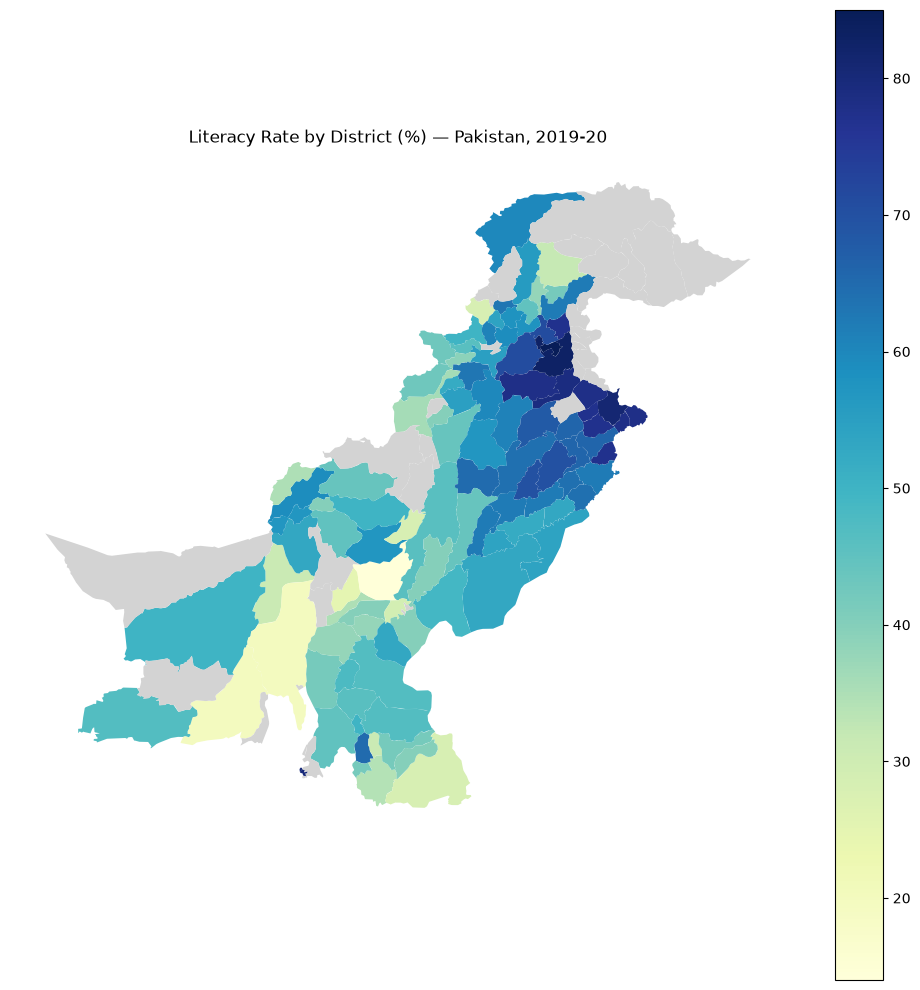

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(column="Total_literacy", cmap="YlGnBu", legend=True, ax=ax,
            missing_kwds={"color": "lightgrey", "label": "No data"})
ax.set_title("Literacy Rate by District (%) — Pakistan, 2019-20")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Literacy is highest (darkest) in northeastern Punjab and lowest (palest) across Baluchistan, with Sindh mixed — strong urban centers alongside a weaker rural interior. This broadly matches Pakistan's known literacy geography, giving some confidence the join didn't introduce systematic distortion. Grey districts are the honestly-documented missing data: administrative exclusions (AJK, Gilgit-Baltistan), disputed-territory entries, and the five genuine survey-coverage gaps identified above.

**Known limitation, discovered later in this notebook:** five coastal districts (Lasbela, Gwadar, Thatta, Karachi South, Karachi West) have malformed source geometry — likely imprecise coastline digitization in this open-source boundary file — that could not be repaired, even by the `on_invalid="fix"` load-time correction. This means these five, including two Karachi districts with genuinely strong data (98–100% toilet access), do not render on this map at all, rather than appearing as an honest grey "no data" gap. Their survey values remain correct in the underlying table. See the distance-to-city section below for the full diagnosis.

## Toilet access choropleth

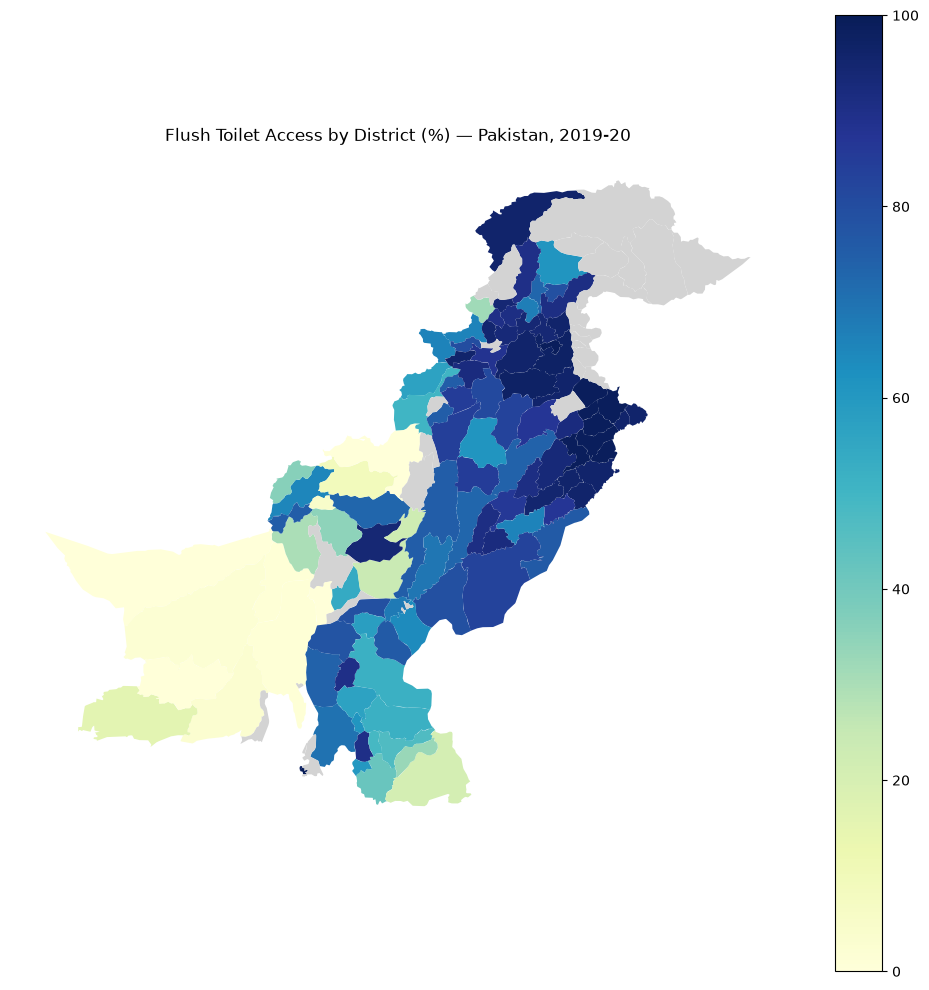

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(column="Total_toilet", cmap="YlGnBu", legend=True, ax=ax,
            missing_kwds={"color": "lightgrey", "label": "No data"})
ax.set_title("Flush Toilet Access by District (%) — Pakistan, 2019-20")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Western Baluchistan shows near-0% flush access — a much starker drop than literacy showed for the same region, an early signal that the two indicators diverge there. Karachi's small southern districts appear less visually prominent than the large northern blue block, partly due to map scale and partly because two of the four Karachi districts (South and West) do not render at all — see the coastal-geometry limitation noted above and diagnosed fully below.

## Data quality investigation: districts with 0% flush toilet access

A closer look at districts reporting 0% urban or 0% rural flush access, to determine whether these reflect real sanitation conditions or artifacts of the data.

In [9]:
print(toilet.groupby("ProvinceID")["Name"].count())
print(toilet[["ProvinceID", "Name"]].drop_duplicates(subset="ProvinceID"))

ProvinceID
1    37
2    28
3    31
4    33
Name: Name, dtype: int64
    ProvinceID        Name
0            1      Attock
37           2       Badin
65           3  Abbottabad
96           4      Awaran


ProvinceID maps cleanly to province: 1=Punjab, 2=Sindh, 3=KP, 4=Baluchistan.

In [10]:
zero_rural = toilet[toilet["Total R"] == 0]
print(f"Districts with 0% rural flush access: {len(zero_rural)}")
print(zero_rural[["Name", "Total U", "Total R", "Total"]])

zero_urban = toilet[toilet["Total U"] == 0]
print(f"\nDistricts with 0% urban flush access: {len(zero_urban)}")
print(zero_urban[["Name", "Total U", "Total R", "Total"]])

Districts with 0% rural flush access: 10
                Name  Total U  Total R  Total
17            Lahore       99        0     99
43   Karachi central       98        0     98
44      Karachi East      100        0    100
46     Karachi South      100        0    100
50           Korangi      100        0    100
98            Chagai        0        0      0
103       Jhal Magsi        0        0      0
113        Musa Khel        0        0      0
116          panjgur        0        0      0
126             zhob        0        0      0

Districts with 0% urban flush access: 22
                      Name  Total U  Total R  Total
67                Batagram        0       79     79
68                   Buner        0       67     67
77                Kohistan        0       61     61
78                  Kurram        0       66     66
84                 Mohmand        0       32     32
85        North waziristan        0       57     57
87                 orakzai        0       80   

Two patterns emerge at opposite extremes. Major cities (Lahore, all Karachi districts) show 0% *rural* access — consistent with these districts having little or no rural population left to sample, not a genuine sanitation failure. Remote, mountainous KP and Baluchistan districts (Batagram, Kohistan, Kurram, Mohmand, Shangla, the Waziristans, several Baluchistan districts) show 0% *urban* access — initially assumed to reflect a similarly negligible urban population.

**A note on 0% flush toilet districts.** Pakistan's official "Flush" category includes pit-connected pour-flush toilets, not only piped or cistern-based systems — confirmed by checking PBS's own indicator definitions (Flush = connected to public sewerage, connected to pit, or to open drain). This matters because personal observation of these regions suggests pit-connected, manually-flushed toilets are common in villages there and should, by definition, qualify as "Flush." Two explanations remain open and can't be fully resolved with the data available: the district's urban population may be too small to register a reliable percentage (a sampling artifact), or these specific districts may genuinely rely on fully dry, unconnected sanitation with no water-pour step at all. Resolving which explanation applies would require district-level population and sample-size data not available in this dataset.

In [11]:
u_zero = toilet[toilet["Total U"] == 0]
mismatch_u = u_zero[u_zero["Total"] != u_zero["Total R"]]
print(f"Districts where U=0 but Total != R: {len(mismatch_u)}")
print(mismatch_u[["Name", "Total U", "Total R", "Total"]])

r_zero = toilet[toilet["Total R"] == 0]
mismatch_r = r_zero[r_zero["Total"] != r_zero["Total U"]]
print(f"\nDistricts where R=0 but Total != U: {len(mismatch_r)}")
print(mismatch_r[["Name", "Total U", "Total R", "Total"]])

Districts where U=0 but Total != R: 1
       Name  Total U  Total R  Total
107  Kharan        0        3      2

Districts where R=0 but Total != U: 0
Empty DataFrame
Columns: [Name, Total U, Total R, Total]
Index: []


A systematic check confirms the pattern holds for 21 of 22 districts where U=0 (Total exactly equals R, consistent with a negligible/unmeasured urban population). One exception, Kharan, shows a genuinely lower Total than R despite U=0 — suggesting a real, if small, measured urban population with near-zero flush access there specifically, rather than a sampling gap. A mirror check on the rural side (R=0 cases) found zero exceptions — Total always equals the urban figure exactly, confirming the pattern holds cleanly in that direction.

### Confirming Karachi's apparent map underrepresentation is a scale illusion, not a data issue

In [12]:
print(merged[merged["NAME_3"].str.contains("Karachi", case=False, na=False)][["NAME_3", "Total_literacy", "Total_toilet"]])

              NAME_3  Total_literacy  Total_toilet
122  Karachi Central            80.0          98.0
123     Karachi East            80.0         100.0
124    Karachi South            75.0         100.0
125     Karachi west            65.0          98.0


Karachi's districts show 65–80% literacy and 98–100% toilet access — as high as anything in the north. They appear visually less prominent on the map purely because Karachi's districts are geographically small compared to Punjab's large northern districts, not because the underlying values are lower. Within Karachi, West Karachi trails its sibling districts by 10–15 literacy points — a real intra-city gap, plausibly linked to lower-income settlement areas, though this is contextual knowledge rather than something the dataset itself confirms.

## Does literacy correlate with toilet access across districts?

**Hypothesis (written before running the analysis):** districts with higher literacy will also show higher toilet access, since both broadly reflect a district's general level of development.

                Total_literacy  Total_toilet
Total_literacy        1.000000      0.751204
Total_toilet          0.751204      1.000000


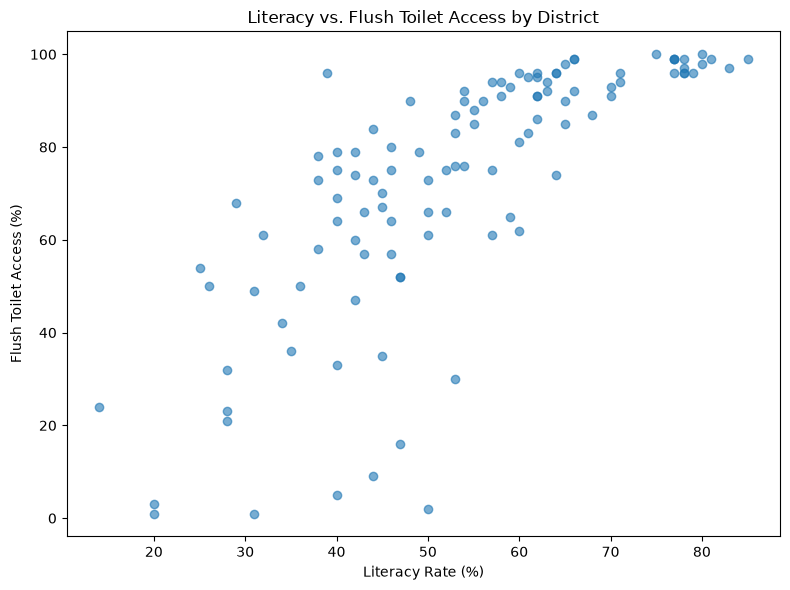

In [13]:
correlation = merged[["Total_literacy", "Total_toilet"]].corr()
print(correlation)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["Total_literacy"], merged["Total_toilet"], alpha=0.6)
ax.set_xlabel("Literacy Rate (%)")
ax.set_ylabel("Flush Toilet Access (%)")
ax.set_title("Literacy vs. Flush Toilet Access by District")
plt.tight_layout()
plt.show()

**The exact correlation coefficient is r = 0.751 (a strong positive correlation).** The hypothesis is broadly confirmed: a clear positive relationship exists between literacy and toilet access. The shape is not uniform, however. Districts above roughly 70% literacy cluster tightly near 90–100% toilet access with little scatter. Below roughly 50% literacy, the relationship becomes far less predictable — some districts near 45–50% literacy sit at 75–80% toilet access, while others at a nearly identical literacy level sit as low as 9–16%. This means literacy alone does not determine sanitation infrastructure at the lower end; some other factor — terrain, remoteness, or targeted infrastructure investment — drives toilet access independently in those districts.

## Is Baluchistan's low toilet access a real gap or a data-coverage artifact?

The choropleth maps show Baluchistan with moderate, varied literacy but almost uniformly low toilet access — a sharper drop than literacy alone would predict. Before concluding this is a real infrastructure gap, the alternative explanation (thin or missing data coverage in the province) needs to be ruled out.

In [14]:
baloch = merged[merged["NAME_1"] == "Baluchistan"]
print(f"Total Baluchistan districts in boundary file: {len(baloch)}")
print(f"With toilet data: {baloch['Total_toilet'].notna().sum()}")
print(f"With literacy data: {baloch['Total_literacy'].notna().sum()}")
print(baloch[["NAME_3", "Total_literacy", "Total_toilet"]].sort_values("Total_toilet"))

Total Baluchistan districts in boundary file: 28
With toilet data: 23
With literacy data: 20
             NAME_3  Total_literacy  Total_toilet
21       Jhal Magsi             NaN           0.0
23           Chagai             NaN           0.0
18          Panjgur             NaN           0.0
35             Zhob             NaN           0.0
13          Khuzdar            20.0           1.0
11            Kalat            31.0           1.0
12           Kharan            50.0           2.0
8            Awaran            20.0           3.0
30           Ziarat            40.0           5.0
34  Qilla Saifullah            44.0           9.0
17             Kech            47.0          16.0
31          Barkhan            28.0          23.0
27       Dera Bugti            14.0          24.0
15          Mastung            53.0          30.0
29             Sibi            45.0          35.0
25   Qilla Abdullah            35.0          36.0
22        Nasirabad            25.0          54.0
16     

**Conclusion.** Coverage is real and substantial — 23 of 28 Baluchistan districts have toilet data, 20 of 28 have literacy data — ruling out a data-coverage artifact as the explanation. The pattern across nearly every district is stark and consistent: literacy sits in a moderate 20–60% range while toilet access is consistently far lower (0–35% for most districts), including districts with real, non-trivial literacy (e.g. Kech: 47% literacy, 16% toilet access). This is a genuine, well-supported finding, not a data artifact.

Given that Pakistan's official "Flush" category includes pit-connected pour-flush systems (confirmed earlier), the most likely explanation is that Baluchistan genuinely relies on fully dry, non-flush sanitation methods more heavily than other provinces — consistent with the province's remoteness and terrain — though the exact "Non-Flush" breakdown needed to confirm this definitively isn't available in this dataset. One nuance worth keeping: the pattern isn't uniform even within Baluchistan — Quetta (the provincial capital, 75%) and Kholu (94%) sit far above the rest of the province, pointing to an urban-capital-vs-rest divide layered on top of an already-low provincial baseline.

## Does distance from a major city predict literacy and toilet access?

**Hypothesis (written before running the analysis):** districts farther from major cities will show lower literacy and lower toilet access, because remoteness limits infrastructure investment, service delivery, and market access.

Measuring real distance requires reprojecting from plain latitude/longitude (EPSG:4326) into a metric coordinate system — degrees of longitude cover different real-world distances at different latitudes, so a raw coordinate subtraction would give a distorted sense of "how far apart." UTM zone 42N (EPSG:32642) is used here to get distances in real kilometers.

In [15]:
from shapely.geometry import Point

# A few of Pakistan's largest cities, as reference points (lon, lat)
major_cities = gpd.GeoDataFrame({
    "city": ["Karachi", "Lahore", "Islamabad", "Quetta", "Peshawar"],
    "geometry": [Point(67.0011, 24.8607), Point(74.3587, 31.5204),
                 Point(73.0479, 33.6844), Point(66.9750, 30.1798),
                 Point(71.5249, 34.0151)]
}, crs="EPSG:4326")

merged_proj = merged.to_crs("EPSG:32642")
cities_proj = major_cities.to_crs("EPSG:32642")
merged_proj["centroid"] = merged_proj.geometry.centroid

def nearest_city_distance(point):
    if point is None or point.is_empty:
        return None
    return cities_proj.geometry.distance(point).min() / 1000

merged["dist_to_city_km"] = merged_proj["centroid"].apply(nearest_city_distance)

print(merged[["NAME_3", "dist_to_city_km"]].sort_values("dist_to_city_km").head())
print(merged[["NAME_3", "dist_to_city_km"]].sort_values("dist_to_city_km", ascending=False).head())

              NAME_3  dist_to_city_km
44         Islamabad         2.547602
95            Lahore         5.771234
69          Peshawar         5.785656
122  Karachi Central        11.062491
123     Karachi East        11.704773
            NAME_3  dist_to_city_km
17            Kech       416.248286
78   Rahimyar Khan       396.290151
77      Bahawalpur       393.253402
75    Ladakh (Leh)       381.840643
136         Ghotki       369.840366


**Data quality note:** this calculation initially failed with `TypeError: (GeoSeries, NoneType)`, tracing back to five districts (Lasbela, Gwadar, Thatta, Karachi South, Karachi West) whose geometry is `None`. Testing the raw, unrepaired source file reproduced the exact same `GEOSException: Invalid number of points in LinearRing` error seen when this project's boundary file was first loaded weeks earlier — confirming these five coastal districts have genuinely malformed geometry at the source (likely imprecise coastline digitization), not something introduced by the `on_invalid="fix"` repair step. `on_invalid="fix"` correctly converted the unfixable five to `None` rather than crashing the entire load, but this silently excluded them from both earlier choropleth maps as well — not shown as an honest grey gap, simply absent. Their survey data remains valid; only their geometry is broken. A production-grade boundary source (e.g. the official HDX/OCHA dataset) would likely resolve this for a future version of this project.

The nearest and farthest results otherwise look sound: the five closest districts (2–12 km) are the districts containing the reference cities themselves; the farthest (370–420 km) are genuinely remote districts, mostly in southern Punjab and Baluchistan. One disputed-territory entry (Ladakh) appears in the farthest list — expected, since distance is purely geometric and doesn't depend on survey data, but it carries no literacy/toilet values and drops out automatically in the correlation below.

                 dist_to_city_km  Total_literacy  Total_toilet
dist_to_city_km         1.000000       -0.483238     -0.409156
Total_literacy         -0.483238        1.000000      0.751204
Total_toilet           -0.409156        0.751204      1.000000


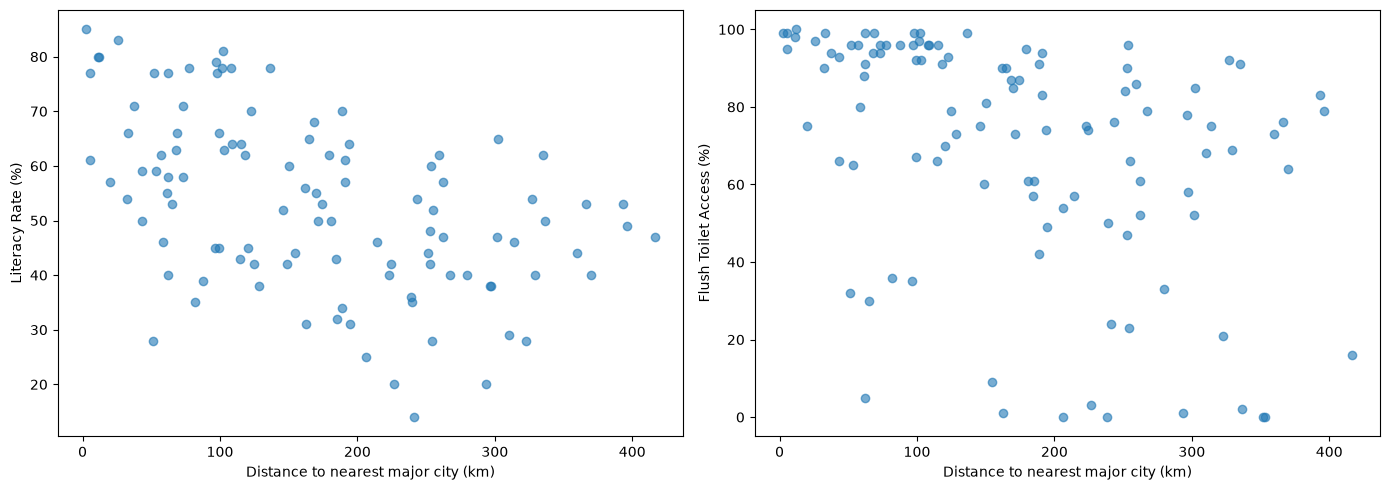

In [16]:
correlation_dist = merged[["dist_to_city_km", "Total_literacy", "Total_toilet"]].corr()
print(correlation_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(merged["dist_to_city_km"], merged["Total_literacy"], alpha=0.6)
axes[0].set_xlabel("Distance to nearest major city (km)")
axes[0].set_ylabel("Literacy Rate (%)")

axes[1].scatter(merged["dist_to_city_km"], merged["Total_toilet"], alpha=0.6)
axes[1].set_xlabel("Distance to nearest major city (km)")
axes[1].set_ylabel("Flush Toilet Access (%)")

plt.tight_layout()
plt.show()

**Conclusion.** The hypothesis is confirmed directionally: distance correlates negatively with both literacy (r = -0.48) and toilet access (r = -0.41) — farther districts do show lower values on average. Literacy is predicted somewhat more reliably by distance than toilet access is. However, both relationships are considerably looser than the literacy-toilet correlation itself (r = 0.75, from the earlier section) — near any given city, literacy ranges almost the full 28–85% span, meaning distance is a real but clearly secondary factor. Something else — most likely general district development or provincial infrastructure investment, which literacy and toilet access capture more directly — matters more than raw geographic distance alone. One notable point: Kech, the single most remote district (416 km from the nearest major city), also shows very low toilet access (~15%) — consistent with, though not fully explaining on its own, the broader Baluchistan pattern documented earlier in this notebook.

## Summary of findings

- **Data quality:** three unrelated data sources required a name-based join; ~30 district-name mismatches were identified and corrected using two independently-verified rename maps (a shared map risked cross-contaminating fixes between the two surveys).
- **Coverage gap:** 5 districts, all in Baluchistan, have genuine one-sided survey coverage (present in one PSLM module, absent from the other) — not a naming error.
- **Geometry limitation:** 5 coastal districts (including 2 in Karachi) have malformed source geometry and could not be rendered on either choropleth map or included in the distance analysis, despite having valid survey data — a boundary-file quality issue, not a survey-data issue.
- **Literacy choropleth:** matches Pakistan's known literacy geography (Punjab highest, Baluchistan lowest), supporting confidence in the data pipeline.
- **0% toilet-access investigation:** most 0% urban/rural figures reflect negligible population in that category rather than genuine zero access; one exception (Kharan) shows a real, small, low-access urban population. Pakistan's "Flush" category includes pit-connected pour-flush toilets, raising an open question about some remote districts' true sanitation type.
- **Literacy vs. toilet access:** strongly positively correlated (r = 0.75) as hypothesized, tightly so above ~70% literacy, but far less predictable below ~50%.
- **Baluchistan:** confirmed as a real, well-covered finding (not a data gap) — toilet access lags far behind what its literacy levels would predict elsewhere in the country, most likely reflecting genuine reliance on non-flush sanitation, with a secondary urban-capital-vs-rest divide within the province.
- **Distance from major cities:** confirmed as a real but secondary predictor (r = -0.48 literacy, r = -0.41 toilet access) — weaker than literacy and toilet access predict each other, suggesting general development matters more than raw geographic remoteness.